<a href="https://colab.research.google.com/github/SHANUKRISHNAN/AFTERNOON-SESSION/blob/main/DAY_7_04_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [98]:
#  ANN
#  sigmoid - binary classification
#  tanh- hidden lyers
#  Relu - 0<  =0
# evaluation - MSE,binary cross entropy,category cross entropy
# gradient descent - optimization algo

In [99]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [100]:
iris=sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [101]:
le=LabelEncoder()
iris['species']=le.fit_transform(iris['species'])
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [102]:
x=iris.drop(['species'],axis=1)
y=iris['species']

In [103]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=12)
x_train.shape,x_test.shape,y_train.shape,y_test.shape


((112, 4), (38, 4), (112,), (38,))

In [104]:
y_test

,species
40,0
146,2
38,0
99,1
143,2
116,2
148,2
39,0
135,2
23,0


In [105]:
std=StandardScaler()
x_train=std.fit_transform(x_train)
x_test=std.transform(x_test)

In [106]:
model=Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(10,activation='relu'))
model.add(Dense(3,activation='softmax')) # multiclass

In [107]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

learned=model.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))

loss, accuracy=model.evaluate(x_test,y_test)
print('Test Loss:',loss)
print('Test Accuracy:',accuracy)



Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.3011 - loss: 1.2487 - val_accuracy: 0.2632 - val_loss: 1.1727
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3489 - loss: 1.1702 - val_accuracy: 0.3421 - val_loss: 1.1150
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4006 - loss: 1.0808 - val_accuracy: 0.4474 - val_loss: 1.0598
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3439 - loss: 1.1089 - val_accuracy: 0.5263 - val_loss: 1.0078
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4713 - loss: 1.0141 - val_accuracy: 0.5263 - val_loss: 0.9586
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5537 - loss: 0.9649 - val_accuracy: 0.5526 - val_loss: 0.9139
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5775 - loss: 0.9084 - val_accuracy: 0.6316 - val_loss: 0.8735
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6314 - loss: 0.8773 - val_accuracy: 0.

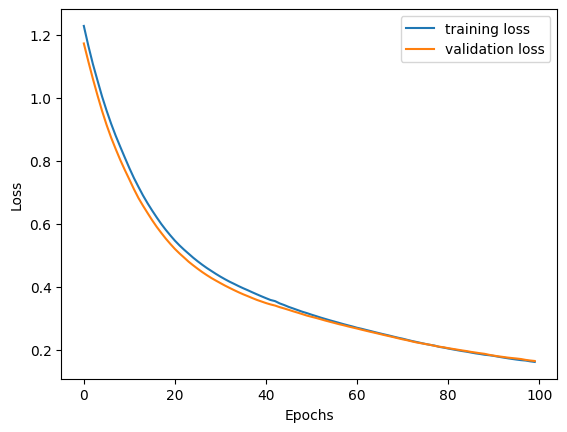

In [108]:
plt.plot(learned.history['loss'],label='training loss')
plt.plot(learned.history['val_loss'],label='validation loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [109]:
predictions=model.predict(x_test)
predicted_classes=np.argmax(predictions,axis=1)
print(predicted_classes)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
[0 2 0 1 2 2 2 0 2 0 1 0 0 0 1 2 2 1 0 1 0 1 2 1 0 2 2 1 0 1 0 1 2 0 2 0 1
 1]


In [110]:
y_test

,species
40,0
146,2
38,0
99,1
143,2
116,2
148,2
39,0
135,2
23,0


In [111]:
new_data=np.array([
    [5.1,3.5,1.4,0.2],
    [6.0,2.7,4.2,1.3]])
new_data=std.transform(new_data)
predictions=model.predict(new_data)
predicted_classes=np.argmax(predictions,axis=1)
predicted_classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0, 1])

In [112]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251 (1008.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 168 (676.00 B)

In [113]:
df=pd.read_csv('/content/Copy of breastcancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [115]:
df.isna().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [116]:
df=df.drop(['Unnamed: 32','id'],axis=1)

In [117]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


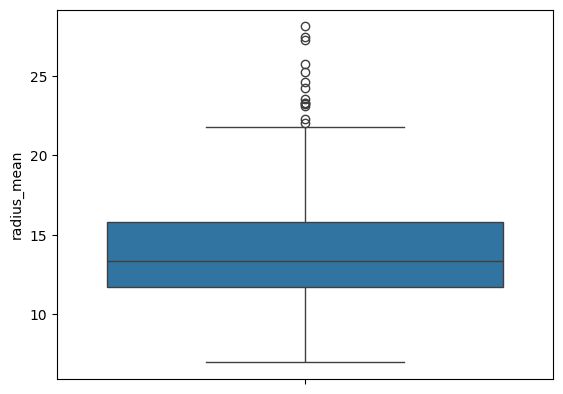

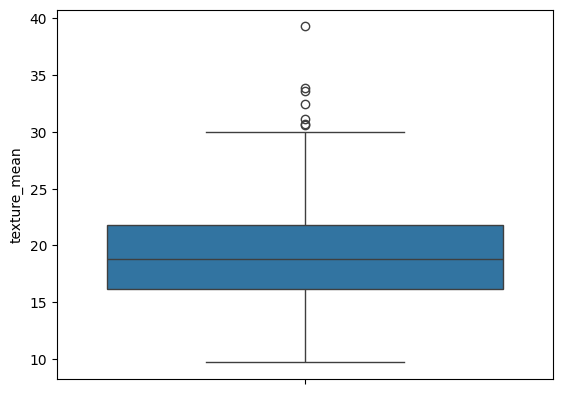

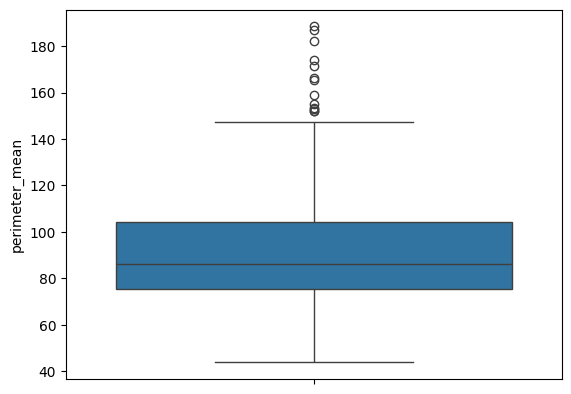

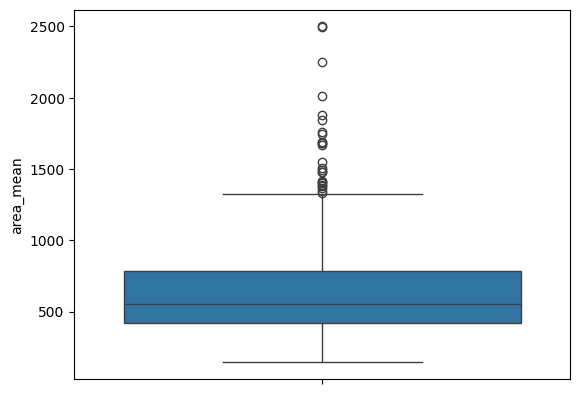

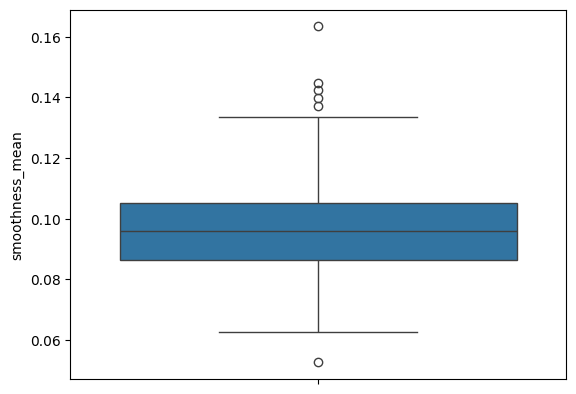

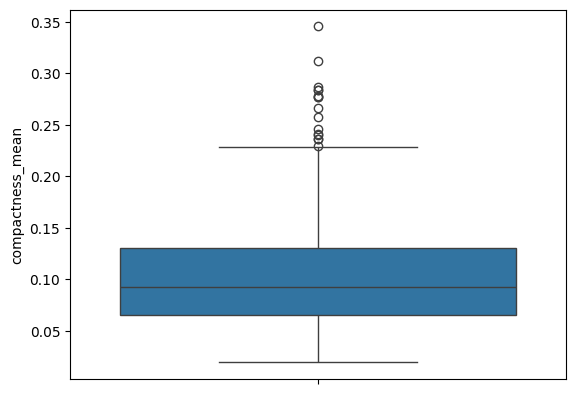

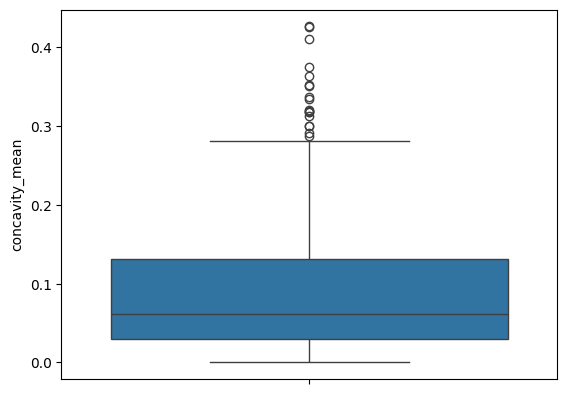

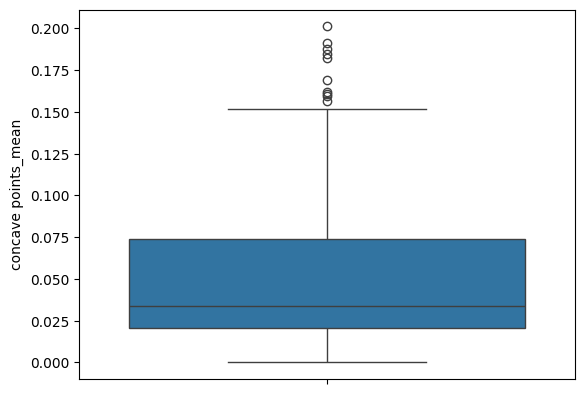

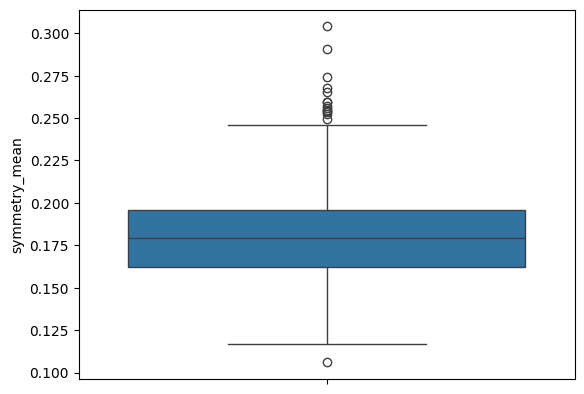

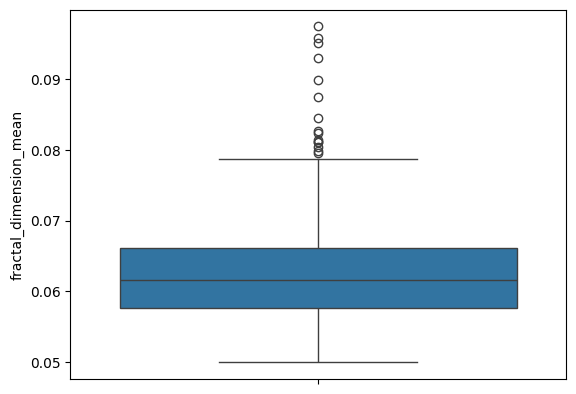

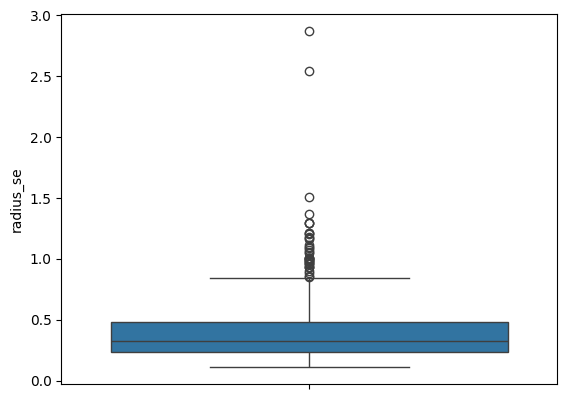

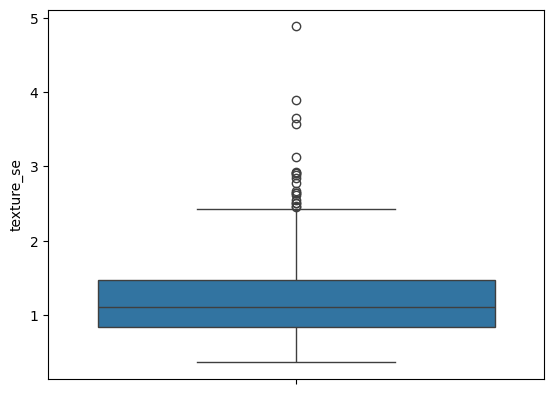

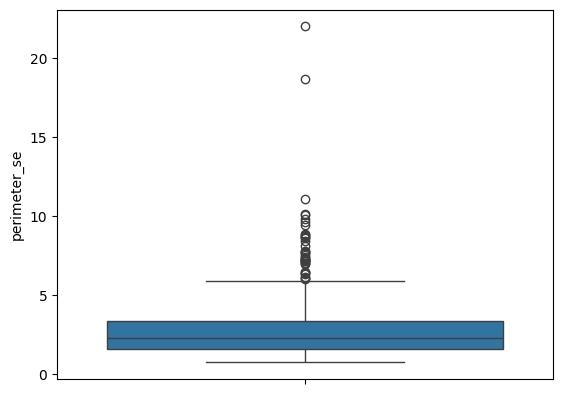

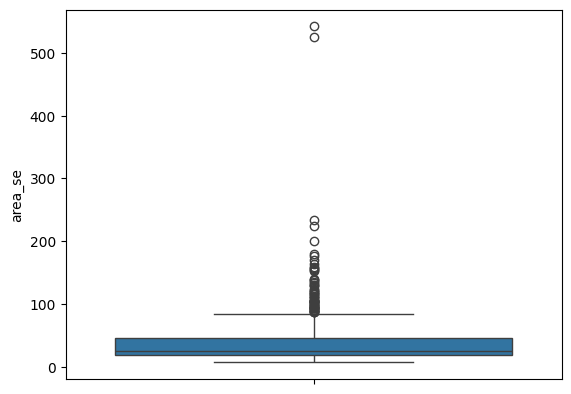

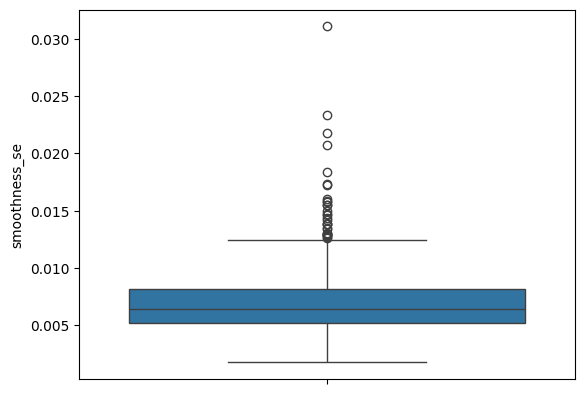

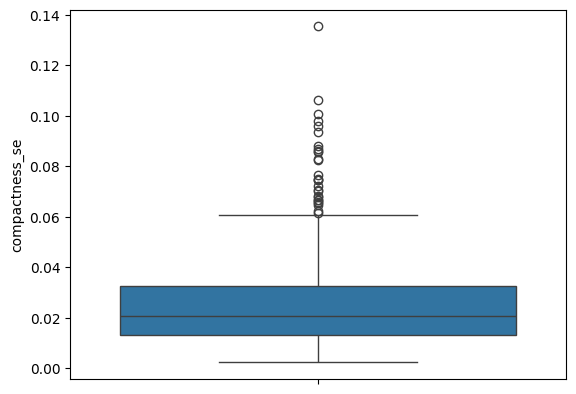

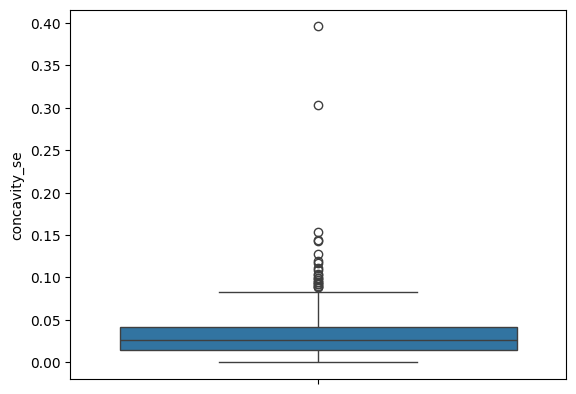

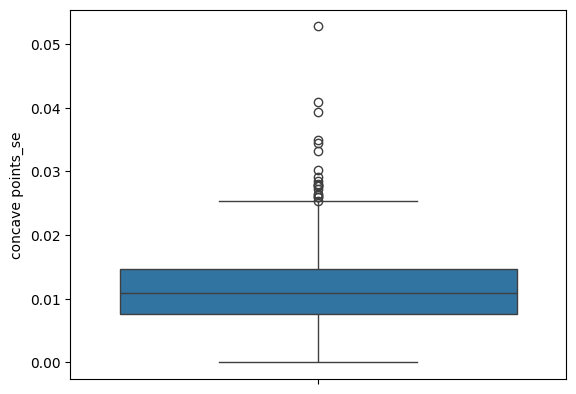

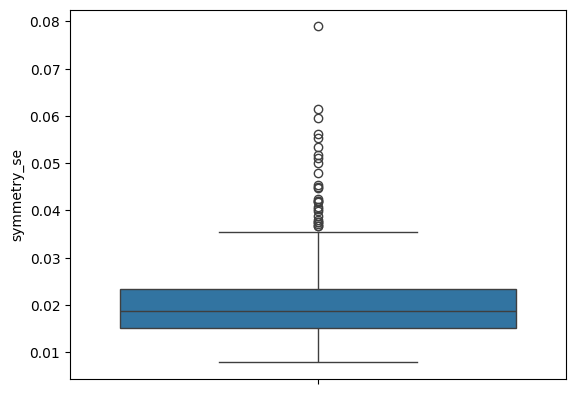

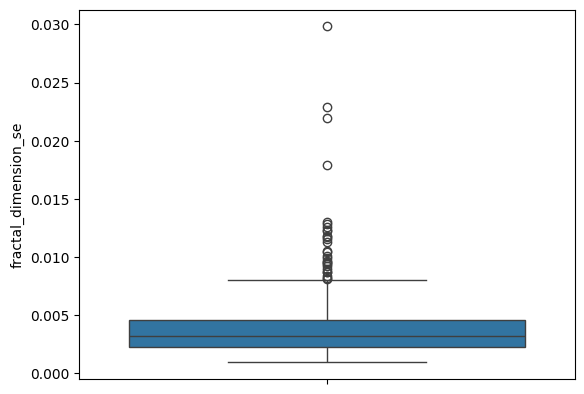

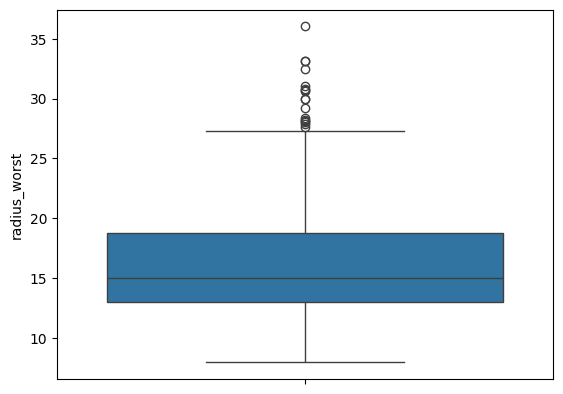

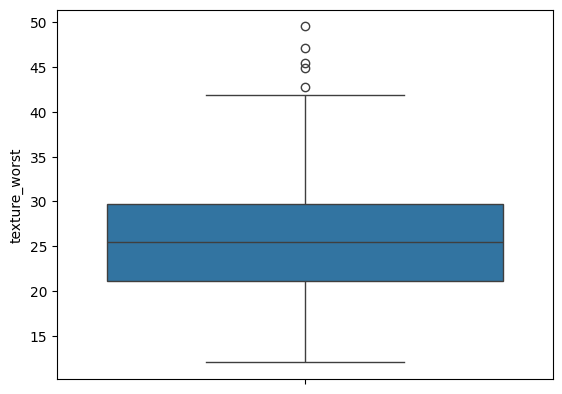

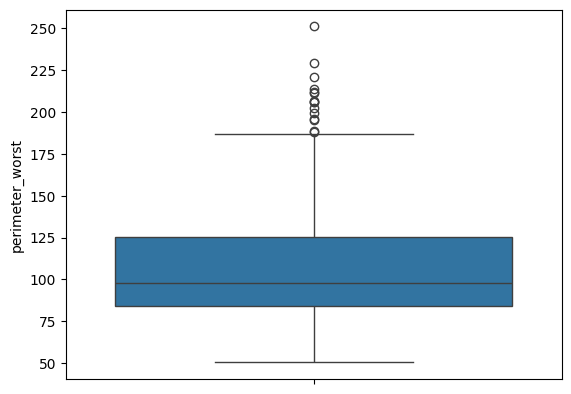

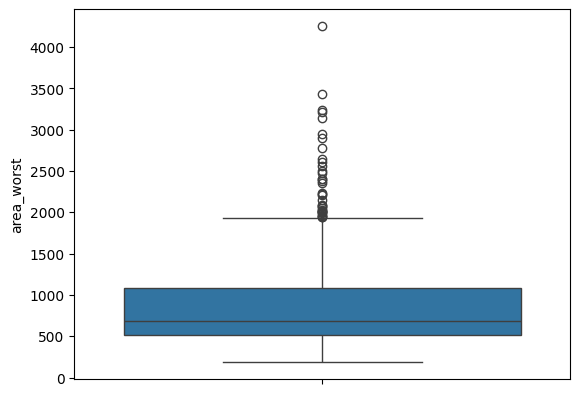

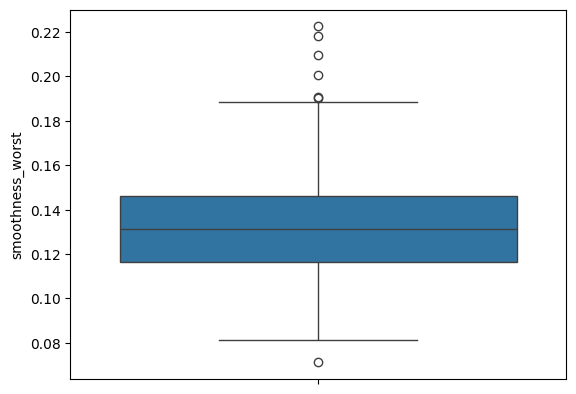

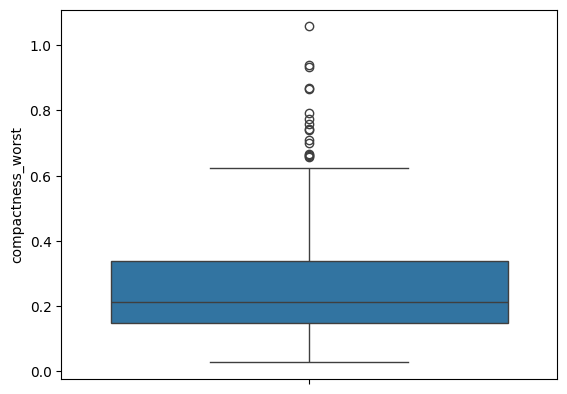

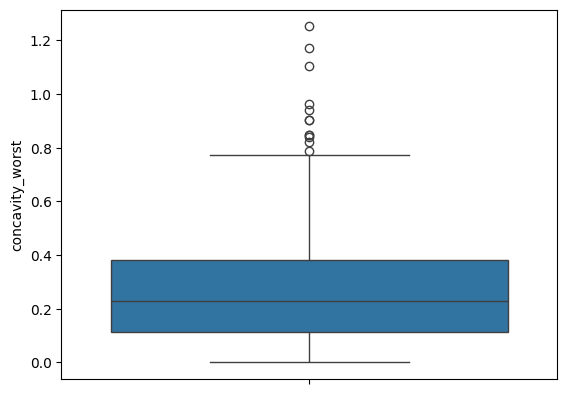

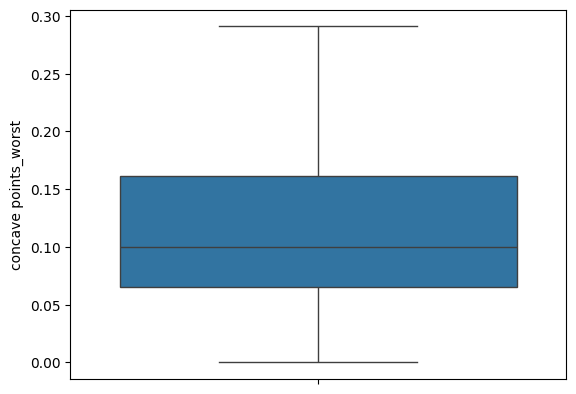

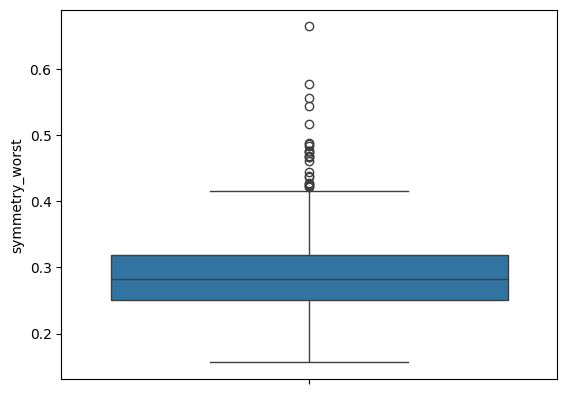

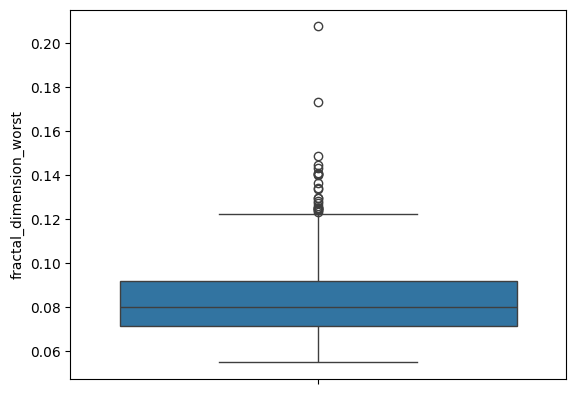

In [118]:
numerical_col=df.select_dtypes(include=np.number).columns
for col in numerical_col:
  sns.boxplot(df[col])
  plt.show()

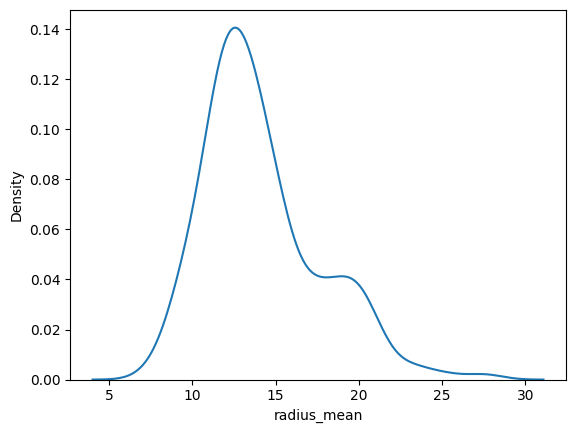

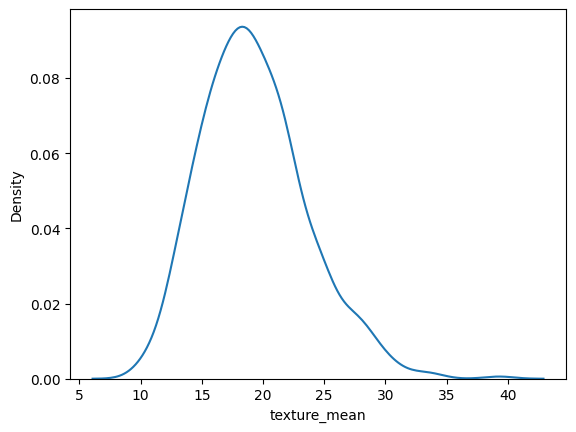

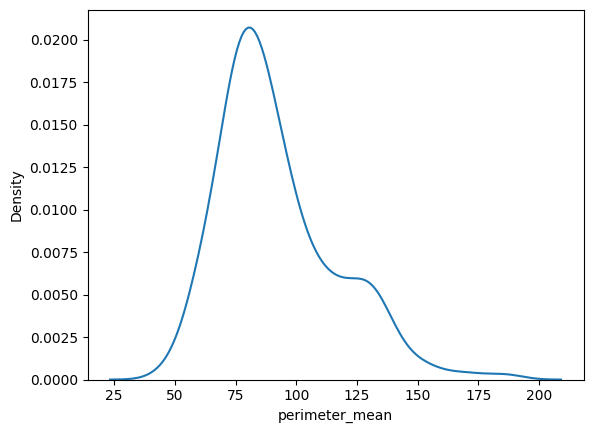

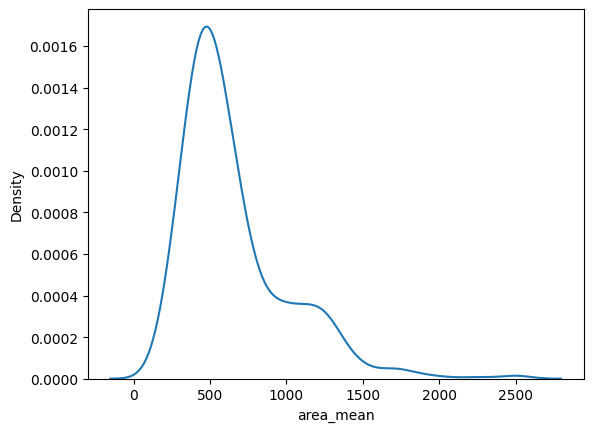

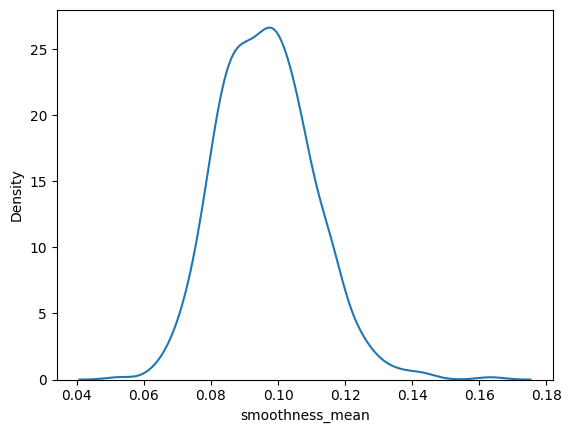

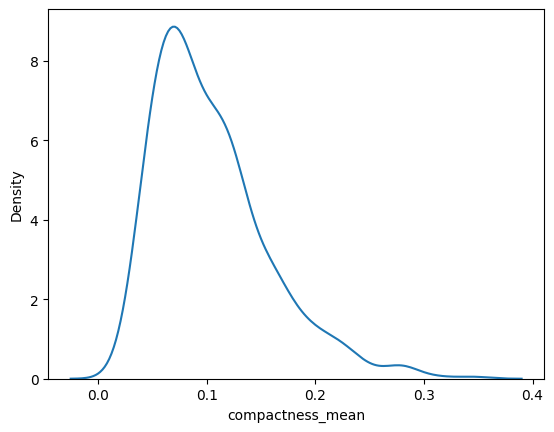

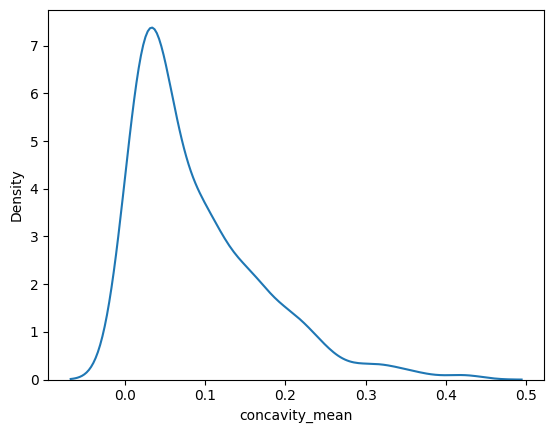

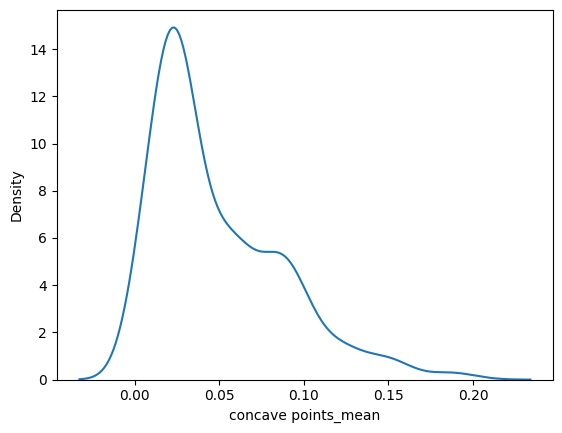

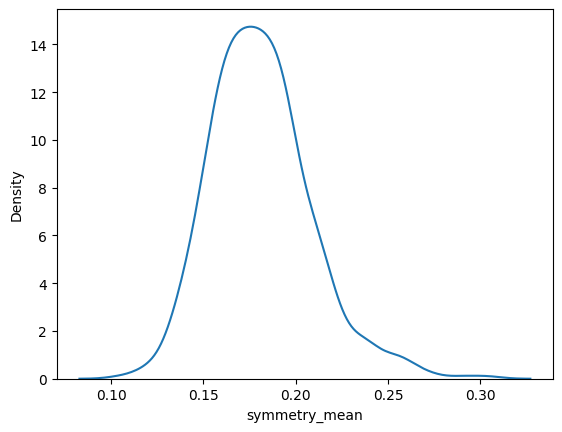

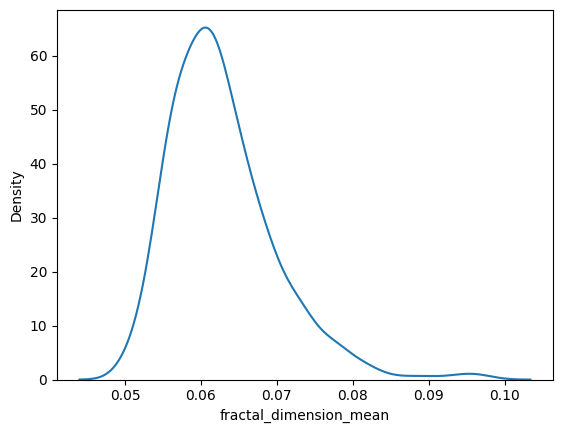

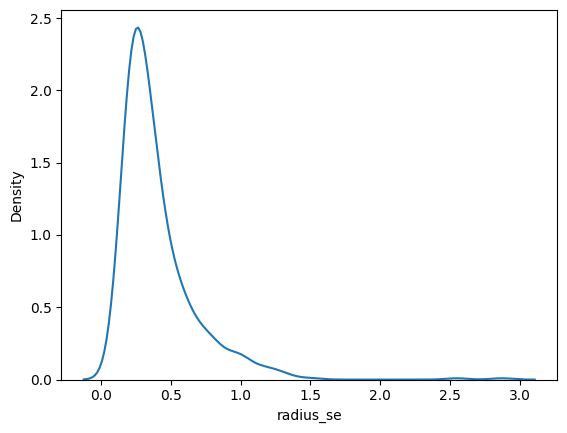

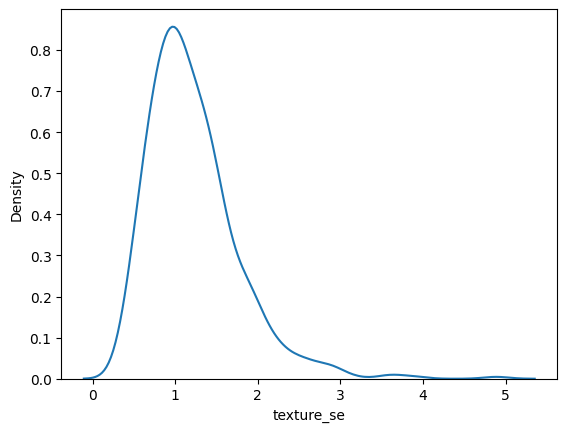

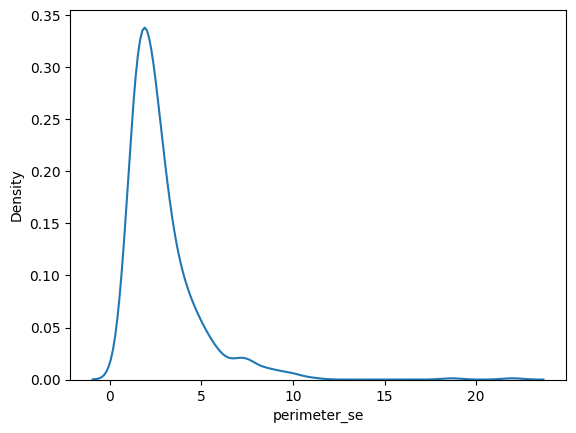

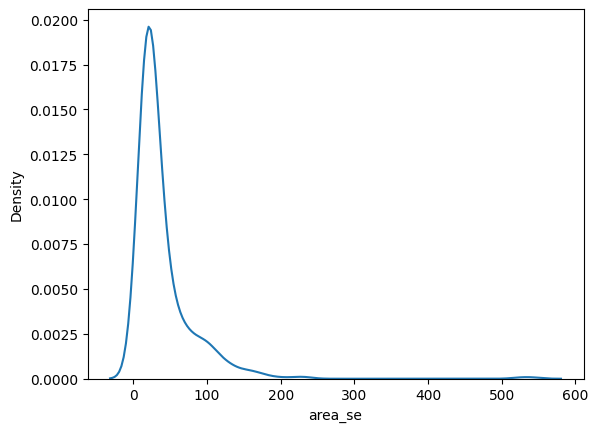

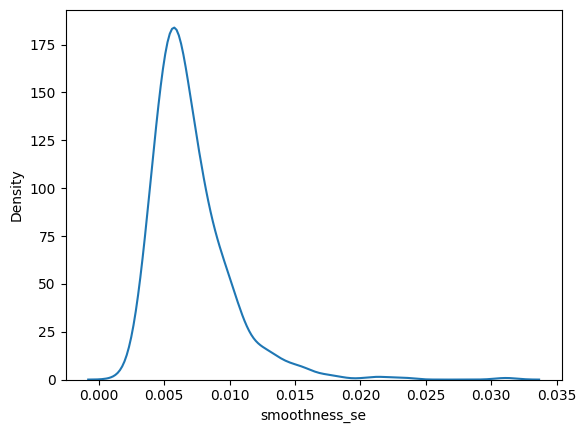

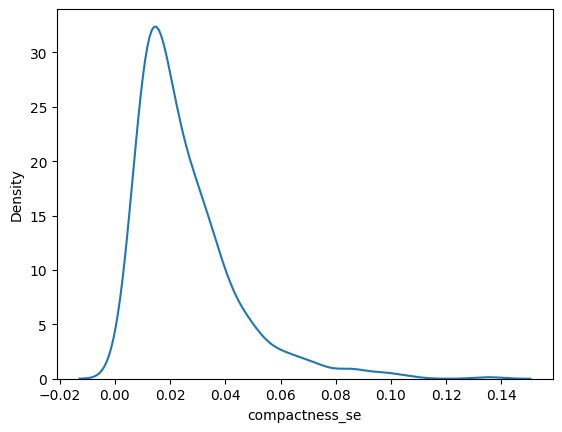

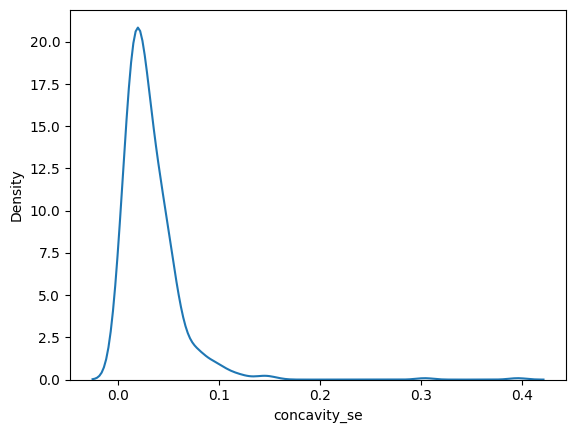

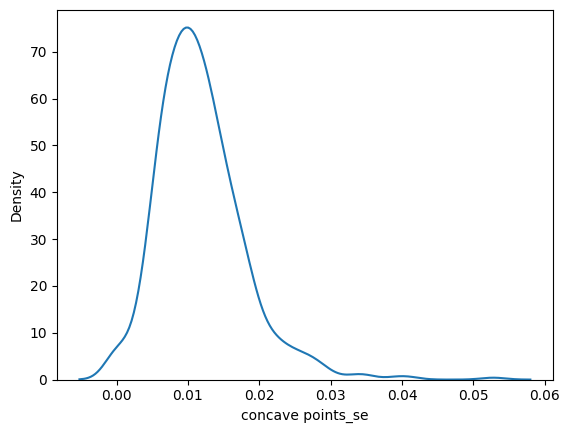

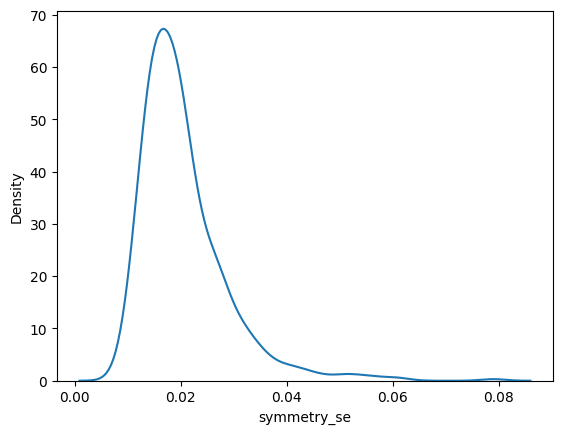

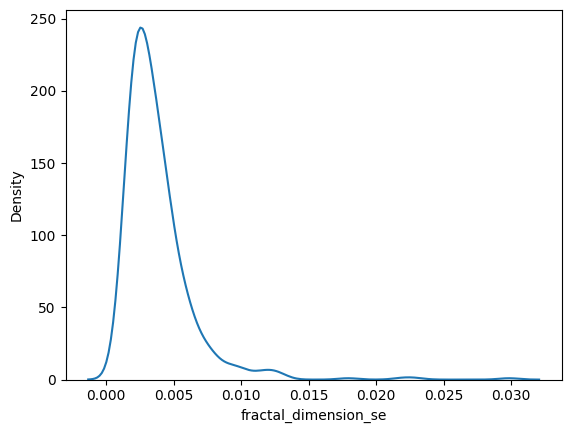

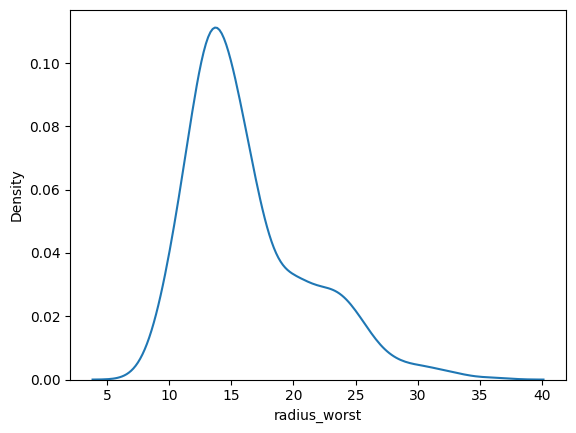

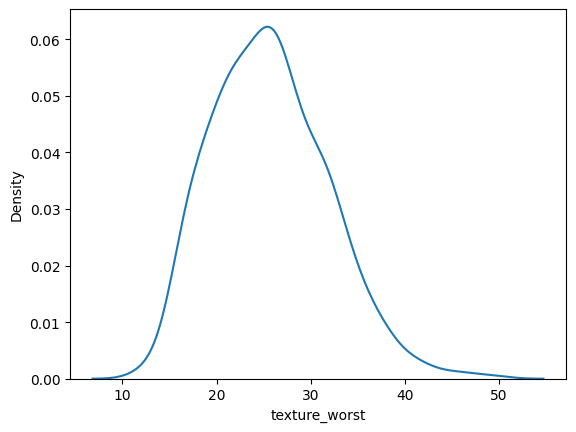

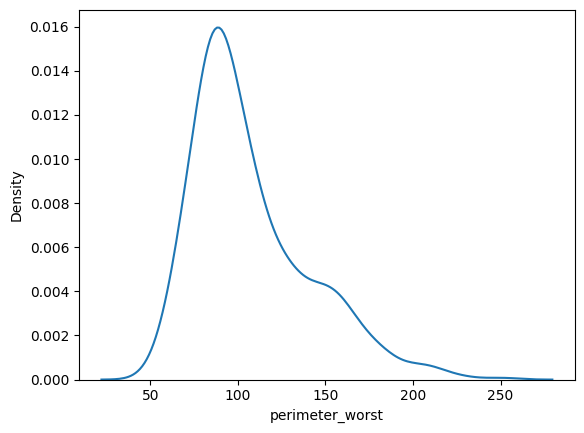

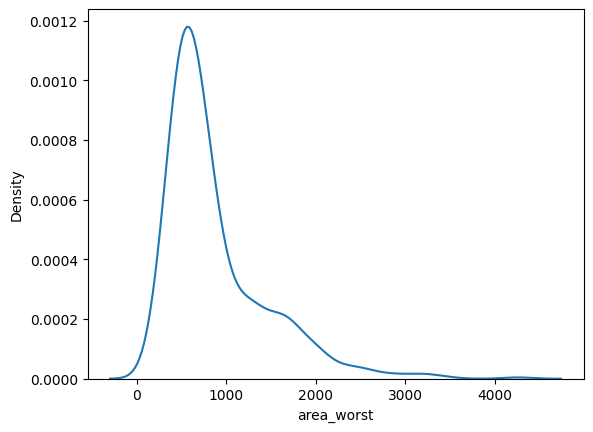

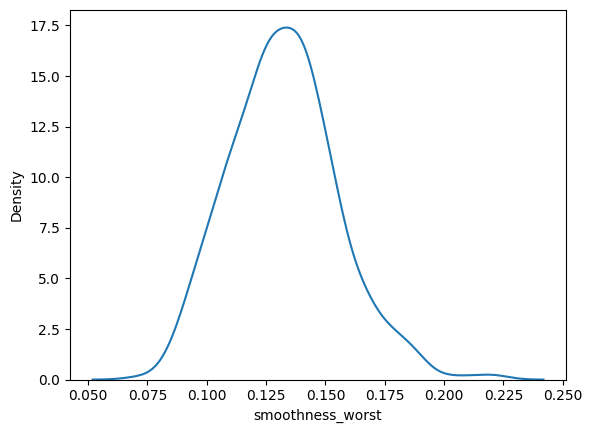

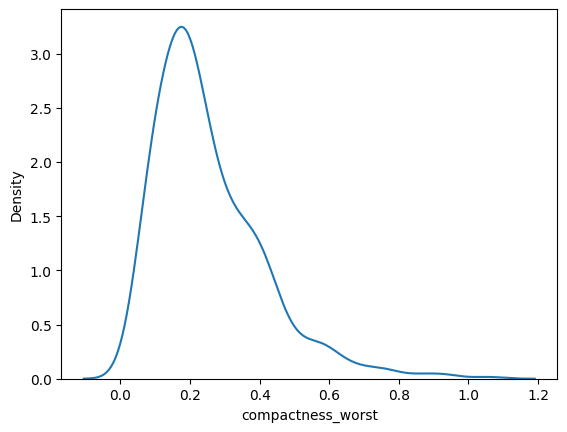

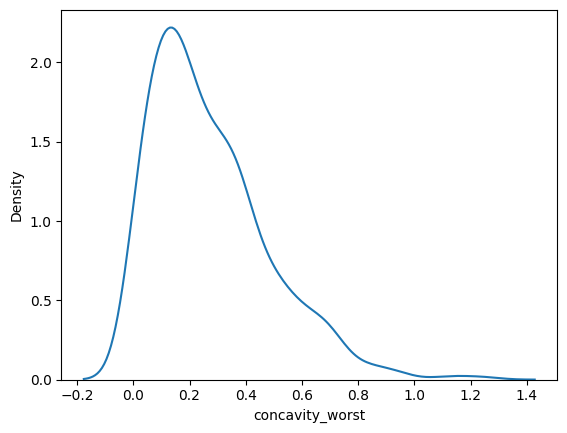

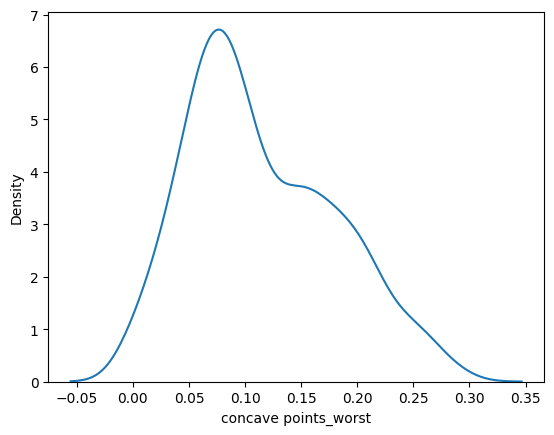

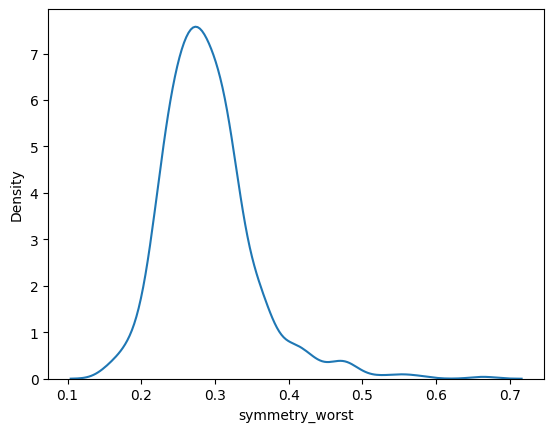

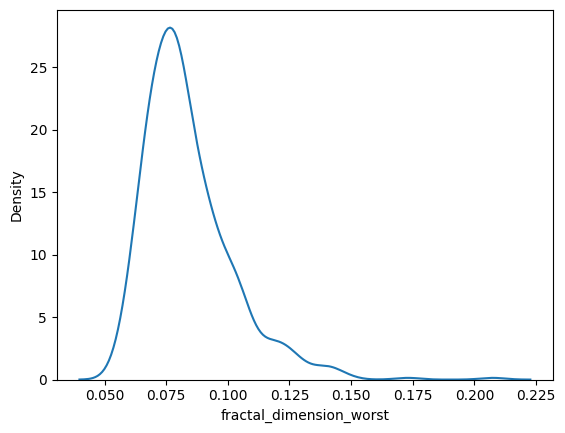

In [119]:
for col in numerical_col:
  sns.kdeplot(df[col])
  plt.show()

In [120]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['diagnosis']=le.fit_transform(df['diagnosis'])
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [121]:
x=df.drop('diagnosis',axis=1)
y=df['diagnosis']
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            5

In [122]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((426, 30), (143, 30), (426,), (143,))

In [123]:
from sklearn.preprocessing import StandardScaler

std=StandardScaler()
x_train=std.fit_transform(x_train)
x_test=std.transform(x_test)

In [124]:
from scipy.stats.mstats import winsorize
import numpy as np

# Calculate the winsorization limits (actual values) from x_train
lower_bound = np.percentile(x_train, 10)
upper_bound = np.percentile(x_train, 90)

# Apply these same bounds to x_train and x_test
x_train = np.clip(x_train, a_min=lower_bound, a_max=upper_bound)
x_test = np.clip(x_test, a_min=lower_bound, a_max=upper_bound)

In [125]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [126]:
model1=Sequential()
model1.add(Input(shape=(30,)))
model1.add(Dense(32,activation='relu'))
model1.add(Dense(16,activation='relu'))
model1.add(Dense(8,activation='relu'))

model1.add(Dense(2,activation='sigmoid')) # Binary Classification

In [127]:
model1.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

learned=model1.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))

loss, accuracy=model1.evaluate(x_test,y_test)
print('Test Loss:',loss)
print('Test Accuracy:',accuracy)



Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7055 - loss: 0.5674 - val_accuracy: 0.9510 - val_loss: 0.2139
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9487 - loss: 0.2044 - val_accuracy: 0.9580 - val_loss: 0.1020
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9631 - loss: 0.1153 - val_accuracy: 0.9650 - val_loss: 0.0818
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9676 - loss: 0.0853 - val_accuracy: 0.9790 - val_loss: 0.0722
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9773 - loss: 0.0686 - val_accuracy: 0.9790 - val_loss: 0.0662
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9828 - loss: 0.0590 - val_accuracy: 0.9790 - val_loss: 0.0649
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9921 - loss: 0.0365 - val_accuracy: 0.9790 - val_loss: 0.0607
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9884 - loss: 0.0358 - val_accuracy: 0.9790 - v

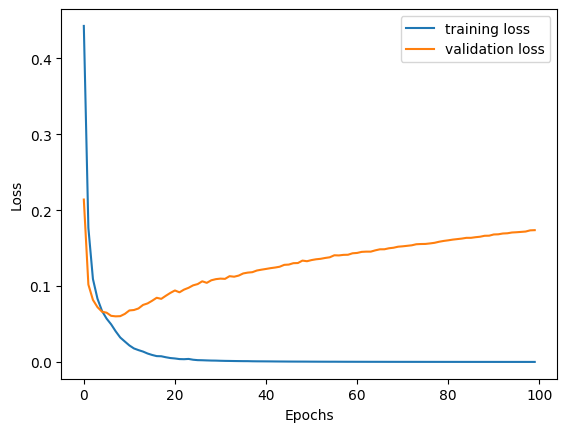

In [128]:
plt.plot(learned.history['loss'],label='training loss')
plt.plot(learned.history['val_loss'],label='validation loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [129]:
predictions=model1.predict(x_test)
predicted_classes=np.argmax(predictions,axis=1)
print(predicted_classes)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0]


In [130]:
y_test

,diagnosis
204,0
70,1
131,1
431,0
540,0
...,...
89,0
199,1
411,0
18,1


In [131]:
new_data=np.array([
    [5.1,3.5,1.4,0.2,5.1,3.5,1.4,0.2,5.1,3.5,1.4,0.2,5.1,3.5,1.4,0.2,5.1,3.5,1.4,0.2,5.1,3.5,1.4,0.2,5.1,3.5,1.4,0.2,2,2],
    [6.0,2.7,4.2,1.3,5.1,3.5,1.4,0.2,5.1,3.5,1.4,0.2,5.1,3.5,1.4,0.2,5.1,3.5,1.4,0.2,5.1,3.5,1.4,0.2,5.1,3.5,1.4,0.2,2,2]])
new_data=std.transform(new_data)
predictions=model1.predict(new_data)
predicted_classes=np.argmax(predictions,axis=1)
predicted_classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1, 1])

In [132]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            5

In [133]:
# Penguin

In [134]:
df2=sns.load_dataset('penguins')
df2

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [135]:
df2.dropna(inplace=True)
df2

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [136]:
x=df2.drop('body_mass_g',axis=1)
y=df2['body_mass_g']


In [137]:
y

,body_mass_g
0,3750.0
1,3800.0
2,3250.0
4,3450.0
5,3650.0
...,...
338,4925.0
340,4850.0
341,5750.0
342,5200.0


In [138]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((249, 6), (84, 6), (249,), (84,))

In [139]:
mode=x_train['sex'].mode()[0]
mean1=x_train['bill_length_mm'].mean()
mean2=x_train['bill_depth_mm'].mean()
mean3=x_train['flipper_length_mm'].mean()

x_train['sex'].fillna(mode,inplace=True)
x_test['sex'].fillna(mode,inplace=True)
x_train['bill_length_mm'].fillna(mean1,inplace=True)
x_test['bill_length_mm'].fillna(mean1,inplace=True)
x_train['bill_depth_mm'].fillna(mean2,inplace=True)
x_test['bill_depth_mm'].fillna(mean2,inplace=True)
x_train['flipper_length_mm'].fillna(mean3,inplace=True)
x_test['flipper_length_mm'].fillna(mean3,inplace=True)


/tmp/ipykernel_359/363731531.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train['sex'].fillna(mode,inplace=True)
/tmp/ipykernel_359/363731531.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.me

In [140]:
print(f'x_test.isna().sum():{x_test.isna().sum()},x_train.isna().sum():{x_train.isna().sum()}')


x_test.isna().sum():species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
sex                  0
dtype: int64,x_train.isna().sum():species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
sex                  0
dtype: int64


In [141]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
ohe_sex = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform 'sex' column of x_train
sex_encoded_train = ohe_sex.fit_transform(x_train[['sex']])


# Transform 'sex' column of x_test
sex_encoded_test = ohe_sex.transform(x_test[['sex']])

# Get the new column names for the encoded 'sex' feature
sex_categories = ohe_sex.get_feature_names_out(['sex'])

# Create DataFrames from the encoded arrays
sex_df_train = pd.DataFrame(sex_encoded_train, columns=sex_categories, index=x_train.index)
sex_df_test = pd.DataFrame(sex_encoded_test, columns=sex_categories, index=x_test.index)

# Drop the original 'sex' column and concatenate the new one-hot encoded columns
x_train = pd.concat([x_train.drop('sex', axis=1), sex_df_train], axis=1)
x_test = pd.concat([x_test.drop('sex', axis=1), sex_df_test], axis=1)

print("x_train head after one-hot encoding 'sex':")
display(x_train.head())
print("\nx_test head after one-hot encoding 'sex':")
display(x_test.head())

x_train head after one-hot encoding 'sex':


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,sex_Female,sex_Male
321,Gentoo,Biscoe,55.9,17.0,228.0,0.0,1.0
265,Gentoo,Biscoe,43.6,13.9,217.0,1.0,0.0
36,Adelie,Dream,38.8,20.0,190.0,0.0,1.0
308,Gentoo,Biscoe,47.5,14.0,212.0,1.0,0.0
191,Chinstrap,Dream,53.5,19.9,205.0,0.0,1.0



x_test head after one-hot encoding 'sex':


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,sex_Female,sex_Male
30,Adelie,Dream,39.5,16.7,178.0,1.0,0.0
317,Gentoo,Biscoe,46.9,14.6,222.0,1.0,0.0
79,Adelie,Torgersen,42.1,19.1,195.0,0.0,1.0
201,Chinstrap,Dream,49.8,17.3,198.0,1.0,0.0
63,Adelie,Biscoe,41.1,18.2,192.0,0.0,1.0


In [142]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
ohe_species = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform 'species' column of x_train
species_encoded_train = ohe_species.fit_transform(x_train[['species']])


# Transform 'species' column of x_test
species_encoded_test = ohe_species.transform(x_test[['species']])

# Get the new column names for the encoded 'species' feature
species_categories = ohe_species.get_feature_names_out(['species'])

# Create DataFrames from the encoded arrays
species_df_train = pd.DataFrame(species_encoded_train, columns=species_categories, index=x_train.index)
species_df_test = pd.DataFrame(species_encoded_test, columns=species_categories, index=x_test.index)

# Drop the original 'species' column and concatenate the new one-hot encoded columns
x_train = pd.concat([x_train.drop('species', axis=1), species_df_train], axis=1)
x_test = pd.concat([x_test.drop('species', axis=1), species_df_test], axis=1)

print("x_train head after one-hot encoding 'species':")
display(x_train.head())
print("\nx_test head after one-hot encoding 'species':")
display(x_test.head())

x_train head after one-hot encoding 'species':


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,sex_Female,sex_Male,species_Adelie,species_Chinstrap,species_Gentoo
321,Biscoe,55.9,17.0,228.0,0.0,1.0,0.0,0.0,1.0
265,Biscoe,43.6,13.9,217.0,1.0,0.0,0.0,0.0,1.0
36,Dream,38.8,20.0,190.0,0.0,1.0,1.0,0.0,0.0
308,Biscoe,47.5,14.0,212.0,1.0,0.0,0.0,0.0,1.0
191,Dream,53.5,19.9,205.0,0.0,1.0,0.0,1.0,0.0



x_test head after one-hot encoding 'species':


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,sex_Female,sex_Male,species_Adelie,species_Chinstrap,species_Gentoo
30,Dream,39.5,16.7,178.0,1.0,0.0,1.0,0.0,0.0
317,Biscoe,46.9,14.6,222.0,1.0,0.0,0.0,0.0,1.0
79,Torgersen,42.1,19.1,195.0,0.0,1.0,1.0,0.0,0.0
201,Dream,49.8,17.3,198.0,1.0,0.0,0.0,1.0,0.0
63,Biscoe,41.1,18.2,192.0,0.0,1.0,1.0,0.0,0.0


In [143]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
ohe_island = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform 'species' column of x_train
island_encoded_train = ohe_island.fit_transform(x_train[['island']])


# Transform 'species' column of x_test
island_encoded_test = ohe_island.transform(x_test[['island']])

# Get the new column names for the encoded 'species' feature
island_categories = ohe_island.get_feature_names_out(['island'])

# Create DataFrames from the encoded arrays
island_df_train = pd.DataFrame(island_encoded_train, columns=island_categories, index=x_train.index)
island_df_test = pd.DataFrame(island_encoded_test, columns=island_categories, index=x_test.index)

# Drop the original 'species' column and concatenate the new one-hot encoded columns
x_train = pd.concat([x_train.drop('island', axis=1), island_df_train], axis=1)
x_test = pd.concat([x_test.drop('island', axis=1), island_df_test], axis=1)

print("x_train head after one-hot encoding 'island':")
display(x_train.head())
print("\nx_test head after one-hot encoding 'island':")
display(x_test.head())

x_train head after one-hot encoding 'island':


,bill_length_mm,bill_depth_mm,flipper_length_mm,sex_Female,sex_Male,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen
321,55.9,17.0,228.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
265,43.6,13.9,217.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
36,38.8,20.0,190.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
308,47.5,14.0,212.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
191,53.5,19.9,205.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0



x_test head after one-hot encoding 'island':


,bill_length_mm,bill_depth_mm,flipper_length_mm,sex_Female,sex_Male,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen
30,39.5,16.7,178.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
317,46.9,14.6,222.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
79,42.1,19.1,195.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
201,49.8,17.3,198.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
63,41.1,18.2,192.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [144]:
numerical_col1=x_train.select_dtypes(include=np.number).columns
numerical_col2=x_test.select_dtypes(include=np.number).columns


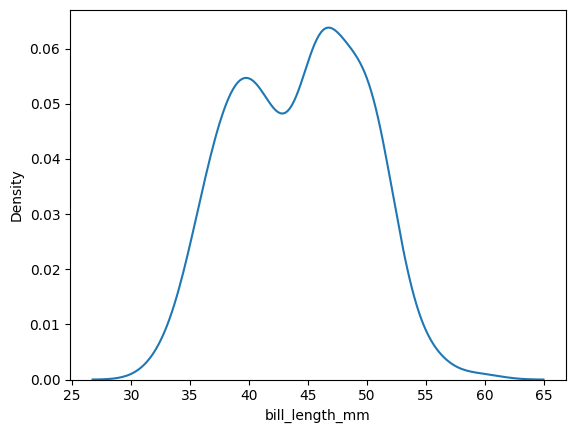

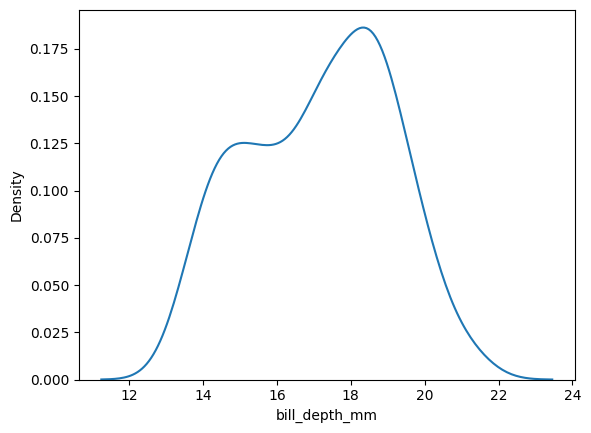

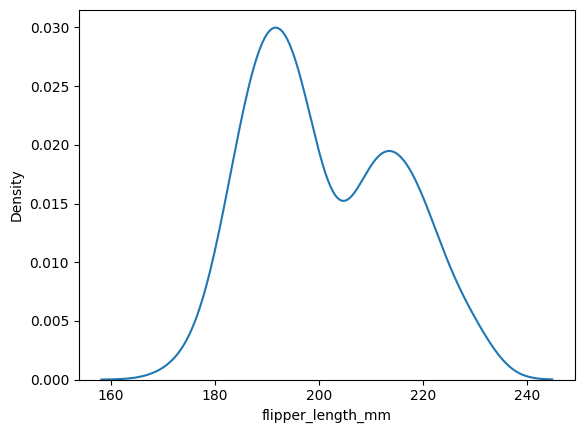

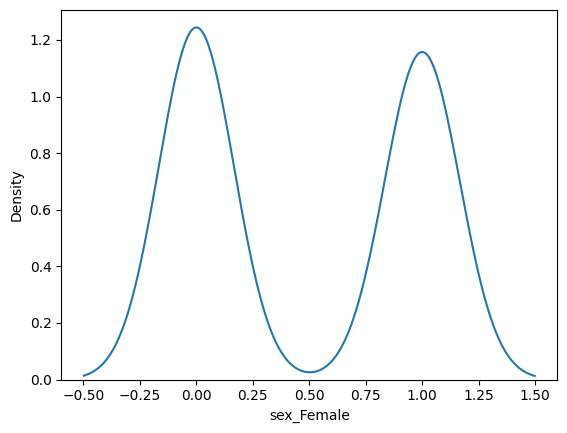

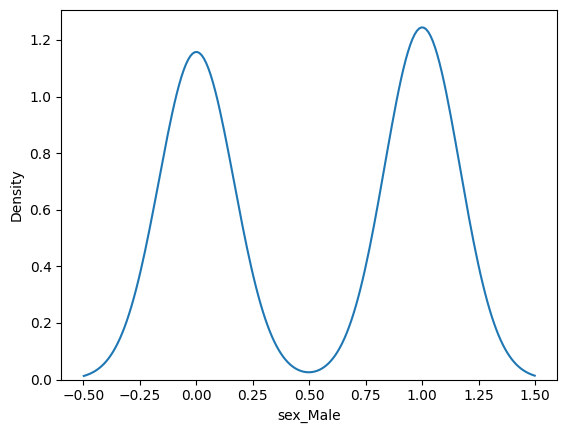

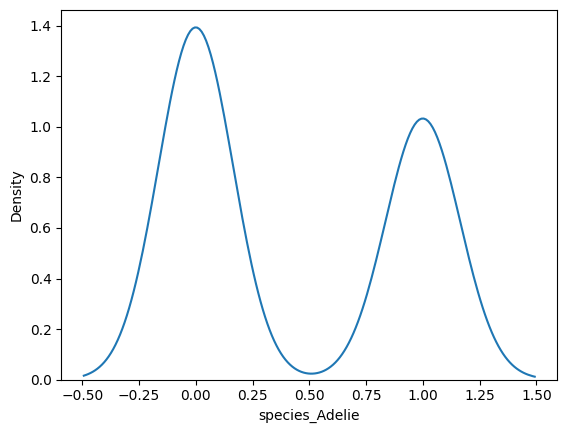

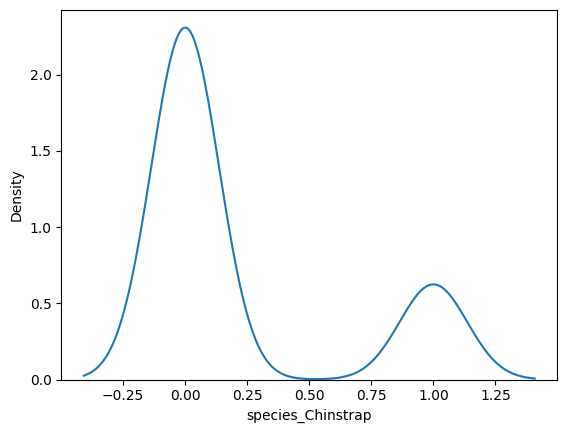

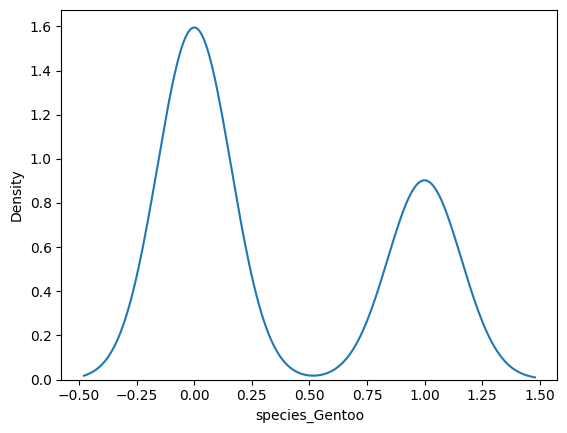

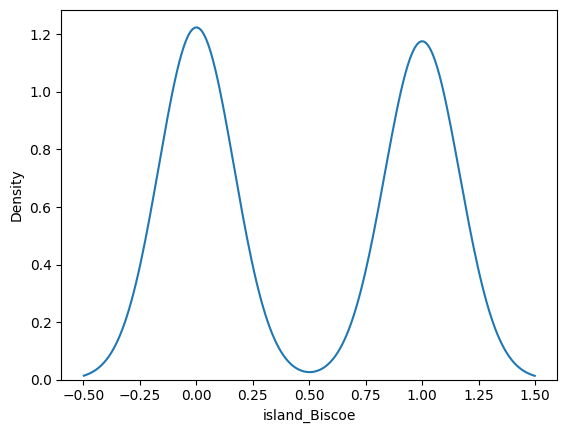

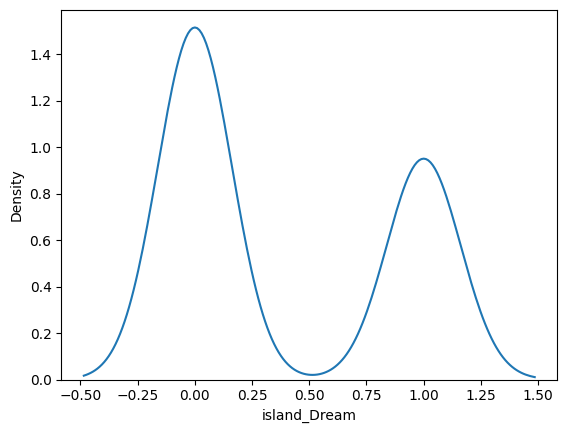

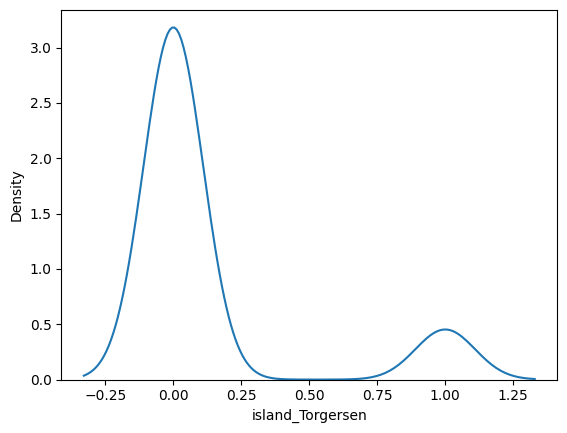

In [145]:
for col2 in numerical_col2:
  sns.kdeplot(x_train[col2])
  plt.show()

In [146]:
from scipy.stats import skew

In [147]:
print(f':{x_train.skew()},\n:{x_test.skew()}')

:bill_length_mm      -0.021285
bill_depth_mm       -0.127693
flipper_length_mm    0.321663
sex_Female           0.072776
sex_Male            -0.072776
species_Adelie       0.302350
species_Chinstrap    1.411558
species_Gentoo       0.580307
island_Biscoe        0.040413
island_Dream         0.473175
island_Torgersen     2.288554
dtype: float64,
:bill_length_mm       0.259193
bill_depth_mm       -0.217430
flipper_length_mm    0.475575
sex_Female          -0.145840
sex_Male             0.145840
species_Adelie       0.097089
species_Chinstrap    1.709182
species_Gentoo       0.662915
island_Biscoe        0.048503
island_Dream         0.778694
island_Torgersen     1.605291
dtype: float64


In [148]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()

In [149]:
x_train=std.fit_transform(x_train)
x_test=std.transform(x_test)

In [150]:
x_train=pd.DataFrame(x_train,columns=numerical_col1)
x_train

,bill_length_mm,bill_depth_mm,flipper_length_mm,sex_Female,sex_Male,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen
0,2.159977,-0.076948,1.942946,-0.964486,0.964486,-0.860964,-0.520008,1.329160,1.020286,-0.792118,-0.377097
1,-0.121497,-1.660848,1.148065,1.036822,-1.036822,-0.860964,-0.520008,1.329160,1.020286,-0.792118,-0.377097
2,-1.011828,1.455858,-0.803007,-0.964486,0.964486,1.161489,-0.520008,-0.752355,-0.980117,1.262438,-0.377097
3,0.601897,-1.609754,0.786755,1.036822,-1.036822,-0.860964,-0.520008,1.329160,1.020286,-0.792118,-0.377097
4,1.714811,1.404764,0.280922,-0.964486,0.964486,-0.860964,1.923048,-0.752355,-0.980117,1.262438,-0.377097
...,...,...,...,...,...,...,...,...,...,...,...
244,1.232548,0.996016,-0.369435,-0.964486,0.964486,-0.860964,1.923048,-0.752355,-0.980117,1.262438,-0.377097
245,-1.308605,1.149297,-1.236578,-0.964486,0.964486,1.161489,-0.520008,-0.752355,-0.980117,-0.792118,2.651841
246,-0.844891,0.280707,-0.586221,1.036822,-1.036822,1.161489,-0.520008,-0.752355,1.020286,-0.792118,-0.377097
247,0.230926,-1.098819,1.364851,-0.964486,0.964486,-0.860964,-0.520008,1.329160,1.020286,-0.792118,-0.377097


In [151]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [152]:
model=Sequential()
model.add(Input(shape=(11,)))

model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(8,activation='relu'))

model.add(Dense(1,activation='linear')) # regression

In [153]:
from sklearn.metrics import r2_score

In [154]:
model.compile(optimizer='adam',loss='mse',metrics=['mae','r2_score'])

learned=model.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))

loss,mae,r2_score=model.evaluate(x_test,y_test)
print('Test Loss:',loss)
print('Test mae:',mae)
print('r2_score:',r2_score)



Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 17608046.0000 - mae: 4118.7881 - r2_score: -26.7311 - val_loss: 18117966.0000 - val_mae: 4184.8496 - val_r2_score: -28.9343
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17872458.0000 - mae: 4155.5225 - r2_score: -30.2481 - val_loss: 18110406.0000 - val_mae: 4183.9653 - val_r2_score: -28.9218
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17939354.0000 - mae: 4163.9473 - r2_score: -29.3356 - val_loss: 18096500.0000 - val_mae: 4182.3350 - val_r2_score: -28.8989
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19139268.0000 - mae: 4297.8491 - r2_score: -28.0671 - val_loss: 18067996.0000 - val_mae: 4178.9956 - val_r2_score: -28.8518
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18086960.0000 - mae: 4168.8501 - r2_score: -25.3600 - val_loss: 18014486.0000 - val_mae: 4172.7070 - val_r2_score: -28.7634
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18277190.0000 - mae: 4198

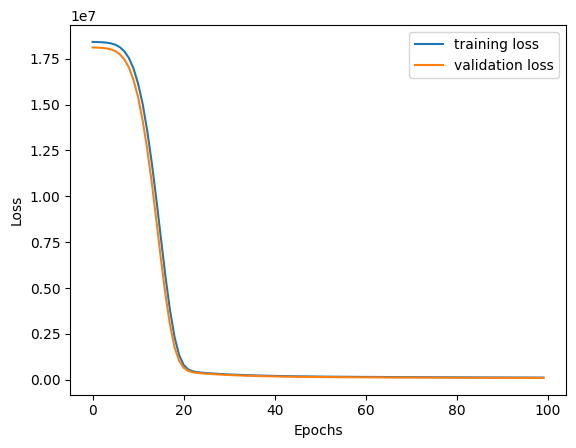

In [155]:
plt.plot(learned.history['loss'],label='training loss')
plt.plot(learned.history['val_loss'],label='validation loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [156]:
df2.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


In [157]:
predictions=model.predict(x_test)
print(predictions)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[[3271.6704]
 [5045.487 ]
 [3859.3235]
 [3261.5264]
 [4012.611 ]
 [4754.3003]
 [5693.971 ]
 [3801.271 ]
 [3716.4102]
 [3874.6133]
 [3481.6892]
 [4491.5713]
 [4501.5806]
 [3392.1196]
 [4545.819 ]
 [3169.7432]
 [3436.8638]
 [3523.184 ]
 [3693.3389]
 [4835.486 ]
 [4136.3457]
 [3483.7793]
 [5841.335 ]
 [4024.8254]
 [3503.2373]
 [3287.0674]
 [4906.797 ]
 [4434.4985]
 [3477.5571]
 [5756.0317]
 [3446.4297]
 [5706.6074]
 [3905.7   ]
 [3193.7573]
 [5639.44  ]
 [4625.389 ]
 [3521.0193]
 [4550.8535]
 [3249.4648]
 [3268.4077]
 [3755.871 ]
 [3355.2114]
 [3401.8503]
 [3202.4639]
 [3832.7283]
 [3247.2456]
 [5423.097 ]
 [3986.266 ]
 [4127.765 ]
 [4889.792 ]
 [3270.4468]
 [5244.007 ]
 [4549.4497]
 [3806.7585]
 [3348.9458]
 [5228.195 ]
 [3363.8533]
 [4397.0146]
 [4016.3032]
 [3808.814 ]
 [5507.4927]
 [4973.435 ]
 [4937.2935]
 [3703.166 ]
 [4137.642 ]
 [5532.122 ]
 [3406.8633]
 [4732.7485]
 [3287.366 ]
 [5546.0903]
 [3291.2642]
 [3849.063 ]
 [4829.8516]
 [4924.4004]


In [158]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,173 (12.40 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,116 (8.27 KB)

In [159]:
import pandas as pd
import numpy as np

# Sample data in original raw format for new predictions
new_raw_data = pd.DataFrame([
    # Example 1: Adelie, Torgersen, Male
    {'species': 'Adelie', 'island': 'Torgersen', 'bill_length_mm': 39.1, 'bill_depth_mm': 18.7, 'flipper_length_mm': 181.0, 'sex': 'Male'},
    # Example 2: Gentoo, Biscoe, Female
    {'species': 'Gentoo', 'island': 'Biscoe', 'bill_length_mm': 46.8, 'bill_depth_mm': 14.3, 'flipper_length_mm': 215.0, 'sex': 'Female'},
    # Example 3: Chinstrap, Dream, Male
    {'species': 'Chinstrap', 'island': 'Dream', 'bill_length_mm': 50.0, 'bill_depth_mm': 19.5, 'flipper_length_mm': 200.0, 'sex': 'Male'}
])

# Apply the same transformations as were applied to x_train and x_test

# 1. Apply one-hot encoding for 'sex' using the fitted ohe_sex encoder
sex_encoded_new = ohe_sex.transform(new_raw_data[['sex']])
sex_df_new = pd.DataFrame(sex_encoded_new, columns=ohe_sex.get_feature_names_out(['sex']), index=new_raw_data.index)

# 2. Apply one-hot encoding for 'species' using the fitted ohe_species encoder
species_encoded_new = ohe_species.transform(new_raw_data[['species']])
species_df_new = pd.DataFrame(species_encoded_new, columns=ohe_species.get_feature_names_out(['species']), index=new_raw_data.index)

# 3. Apply one-hot encoding for 'island' using the fitted ohe_island encoder
island_encoded_new = ohe_island.transform(new_raw_data[['island']])
island_df_new = pd.DataFrame(island_encoded_new, columns=ohe_island.get_feature_names_out(['island']), index=new_raw_data.index)

# Combine the one-hot encoded and original numerical features
# Ensure the columns are in the exact order as the training data's feature order
# The column order is derived from `x_train.columns`
final_feature_columns = x_train.columns.tolist()

new_data_processed = pd.concat([
    new_raw_data[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']],
    sex_df_new,
    species_df_new,
    island_df_new
], axis=1)

# Reorder columns to match the training data's feature order exactly
new_data_processed = new_data_processed[final_feature_columns]

# 4. Apply the StandardScaler transformation using the fitted std scaler
new_data_scaled = std.transform(new_data_processed.values) # Changed here: added .values

# Make predictions using the trained model
predictions = model.predict(new_data_scaled)

print("New data points (original features):")
display(new_raw_data)
print("\nPredicted body masses for the new data points:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
New data points (original features):


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,sex
0,Adelie,Torgersen,39.1,18.7,181.0,Male
1,Gentoo,Biscoe,46.8,14.3,215.0,Female
2,Chinstrap,Dream,50.0,19.5,200.0,Male



Predicted body masses for the new data points:
[[3991.9673]
 [4818.5938]
 [3989.5798]]
